# P01 — Simulador de física no Python

Projeto do portfólio de Data Science para Automação Industrial.

Objetivo: transformar fenômenos físicos simples em dados simulados, usando Python, como ponto de partida para pensar em dados como representações de fenômenos reais.

## Parte 1 — Queda livre

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A função abaixo simula a posição de um objeto em queda livre, usando a equação da cinemática:

$$y(t) = y_0 - \frac{1}{2} g t^2$$

Cada iteração do laço `while` representa uma nova "leitura" de um sensor de altura, registrada a cada `dt` segundos, até o objeto tocar o chão.

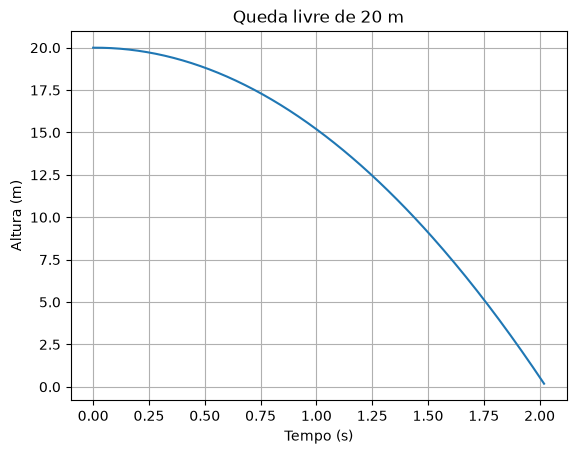

In [3]:
def queda_livre(altura_inicial, g=9.81, dt=0.01):
    """Simula a posição de um objeto em queda livre até tocar o chão."""
    t = 0
    tempos = []
    posicoes = []
    y = altura_inicial

    while y > 0:
        tempos.append(t)
        posicoes.append(y)
        y = altura_inicial - 0.5 * g * t**2
        t += dt

    return np.array(tempos), np.array(posicoes)


t, y = queda_livre(altura_inicial=20)

plt.plot(t, y)
plt.xlabel("Tempo (s)")
plt.ylabel("Altura (m)")
plt.title("Queda livre de 20 m")
plt.grid(True)
plt.savefig("../images/queda_livre.png", dpi=150, bbox_inches="tight")
plt.show()

## Parte 2 — Resfriamento de Newton

A Lei do resfriamento de Newton diz que a taxa com que um objeto esfria é proporcional à diferença entre sua temperatura e a temperatura ambiente:

$$\frac{dT}{dt} = -k(T - T_{ambiente})$$

Resolvendo essa equação diferencial, a temperatura ao longo do tempo é dada por:

$$T(t) = T_{ambiente} + (T_0 - T_{ambiente}) \, e^{-kt}$$

É o tipo de curva que um sensor de temperatura registraria numa peça ou forno esfriando após um ciclo industrial.

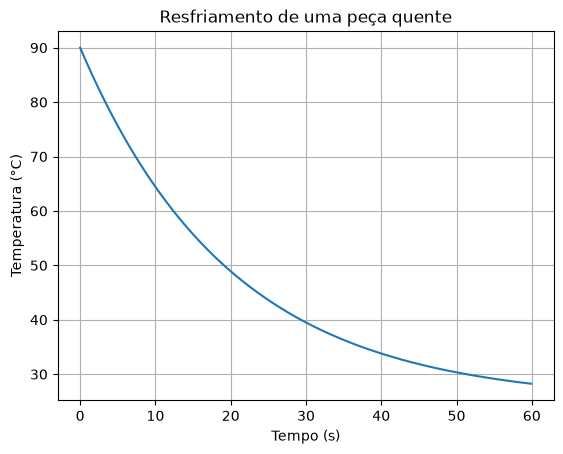

In [3]:
def resfriamento_newton(T0, T_ambiente, k, tempo_total=60, dt=0.1):
    """Lei do resfriamento de Newton: dT/dt = -k(T - T_ambiente)."""
    t = np.arange(0, tempo_total, dt)
    T = T_ambiente + (T0 - T_ambiente) * np.exp(-k * t)
    return t, T


t, T = resfriamento_newton(T0=90, T_ambiente=25, k=0.05)

plt.plot(t, T)
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Resfriamento de uma peça quente")
plt.grid(True)
plt.savefig("../images/resfriamento_newton.png", dpi=150, bbox_inches="tight")
plt.show()

## Parte 3 — Sensor de pressão com ruído

Um sensor de pressão oscilando registra um sinal periódico (senoidal). Mas nenhum sensor real é perfeito: toda medição tem **ruído** — pequenas flutuações aleatórias em torno do valor real.

Aqui vamos simular os dois: o **sinal real** (a física, limpa) e a **leitura do sensor** (o sinal real + ruído), pra ver a diferença entre o fenômeno e a medição dele — algo que vai aparecer em praticamente todo dataset real de sensores industriais a partir do P03.

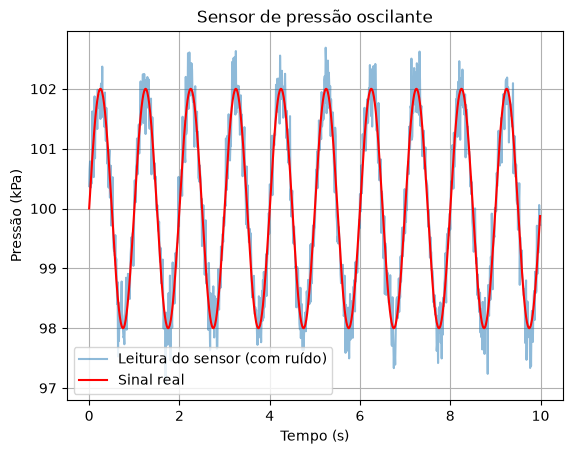

In [4]:
def sensor_pressao(duracao=10, freq=1.0, amplitude=2.0, offset=100, ruido=0.3, dt=0.01):
    """Simula leitura de um sensor de pressão oscilando com ruído de medição."""
    t = np.arange(0, duracao, dt)
    sinal_limpo = offset + amplitude * np.sin(2 * np.pi * freq * t)
    ruido_medicao = np.random.normal(0, ruido, size=t.shape)
    leitura = sinal_limpo + ruido_medicao
    return t, leitura, sinal_limpo


t, leitura, sinal_limpo = sensor_pressao()

plt.plot(t, leitura, alpha=0.5, label="Leitura do sensor (com ruído)")
plt.plot(t, sinal_limpo, color="red", label="Sinal real")
plt.xlabel("Tempo (s)")
plt.ylabel("Pressão (kPa)")
plt.title("Sensor de pressão oscilante")
plt.legend()
plt.grid(True)
plt.savefig("../images/sensor_pressao.png", dpi=150, bbox_inches="tight")
plt.show()